In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
train = pd.read_csv("../train.csv")
stores = pd.read_csv("../stores.csv")
transactions = pd.read_csv("../transactions.csv")
oil = pd.read_csv("../oil.csv")
holidays = pd.read_csv("../holidays_events.csv")

print("Datasets loaded successfully!")


Datasets loaded successfully!


In [3]:
print("Train Shape:", train.shape)
print("Stores Shape:", stores.shape)
print("Transactions Shape:", transactions.shape)
print("Oil Shape:", oil.shape)
print("Holidays Shape:", holidays.shape)

Train Shape: (3000888, 6)
Stores Shape: (54, 5)
Transactions Shape: (83488, 3)
Oil Shape: (1218, 2)
Holidays Shape: (350, 6)


In [4]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [7]:
print("Number of Product Families:", train['family'].nunique())
print("\nProduct Families:\n")
print(train['family'].unique())




Number of Product Families: 33

Product Families:

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [9]:
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False)
family_sales.head(10)

family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64

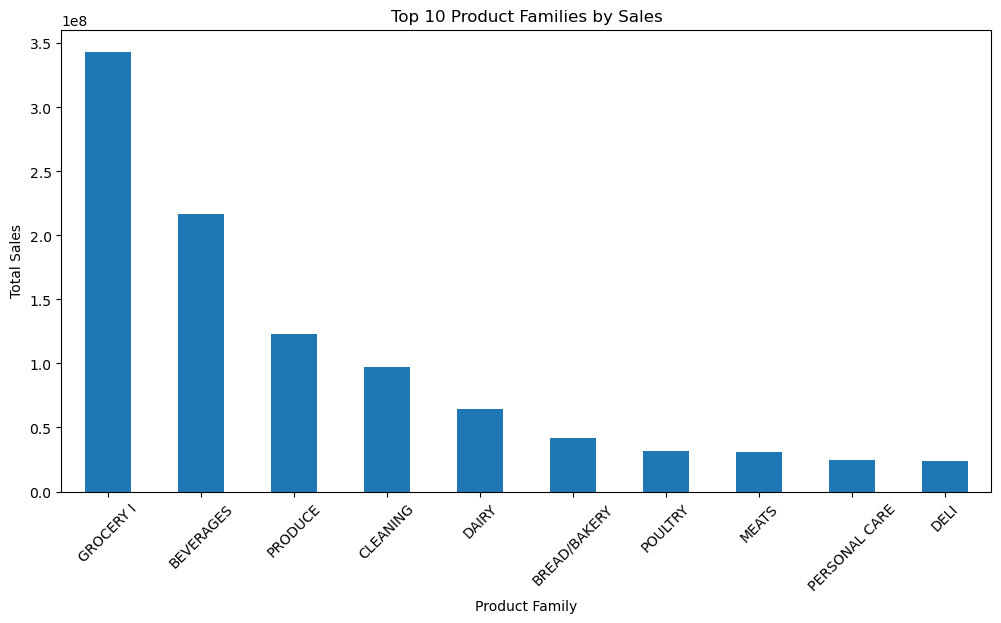

In [10]:
plt.figure(figsize=(12,6))
family_sales.head(10).plot(kind='bar')
plt.title("Top 10 Product Families by Sales")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

In [11]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [12]:
stores.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [13]:
stores.describe()

,store_nbr,cluster
count,54.000000,54.000000
mean,27.500000,8.481481
std,15.732133,4.693395
min,1.000000,1.000000
25%,14.250000,4.000000
50%,27.500000,8.500000
75%,40.750000,13.000000
max,54.000000,17.000000


In [14]:
sales_city = train.merge(
    stores,
    on = 'store_nbr',
    how='left')
sales_city.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [15]:
sales_city.shape

(3000888, 10)

In [16]:
city_sales = (
    sales_city
    .groupby('city')['sales']
    .sum()
    .sort_values(ascending=False)
)

city_sales.head(10)


city
Quito            5.567418e+08
Guayaquil        1.229673e+08
Cuenca           4.916860e+07
Ambato           4.030440e+07
Santo Domingo    3.583432e+07
Machala          3.338680e+07
Cayambe          2.832556e+07
Latacunga        2.118226e+07
Daule            1.918802e+07
Loja             1.886000e+07
Name: sales, dtype: float64

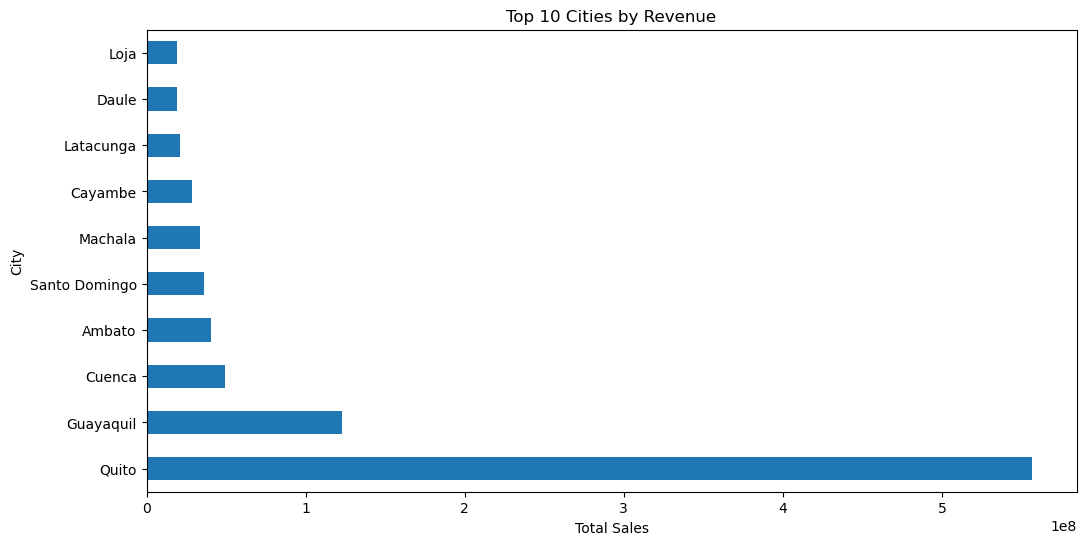

In [17]:
plt.figure(figsize=(12,6))

city_sales.head(10).plot(kind='barh')

plt.title("Top 10 Cities by Revenue")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

In [18]:
city_sales.head(10)

city
Quito            5.567418e+08
Guayaquil        1.229673e+08
Cuenca           4.916860e+07
Ambato           4.030440e+07
Santo Domingo    3.583432e+07
Machala          3.338680e+07
Cayambe          2.832556e+07
Latacunga        2.118226e+07
Daule            1.918802e+07
Loja             1.886000e+07
Name: sales, dtype: float64

In [20]:
city_sales.head(10).apply(lambda x: round(x/1000000,2))

city
Quito            556.74
Guayaquil        122.97
Cuenca            49.17
Ambato            40.30
Santo Domingo     35.83
Machala           33.39
Cayambe           28.33
Latacunga         21.18
Daule             19.19
Loja              18.86
Name: sales, dtype: float64

In [21]:
store_sales = (
    sales_city
    .groupby('store_nbr')['sales']
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
Name: sales, dtype: float64

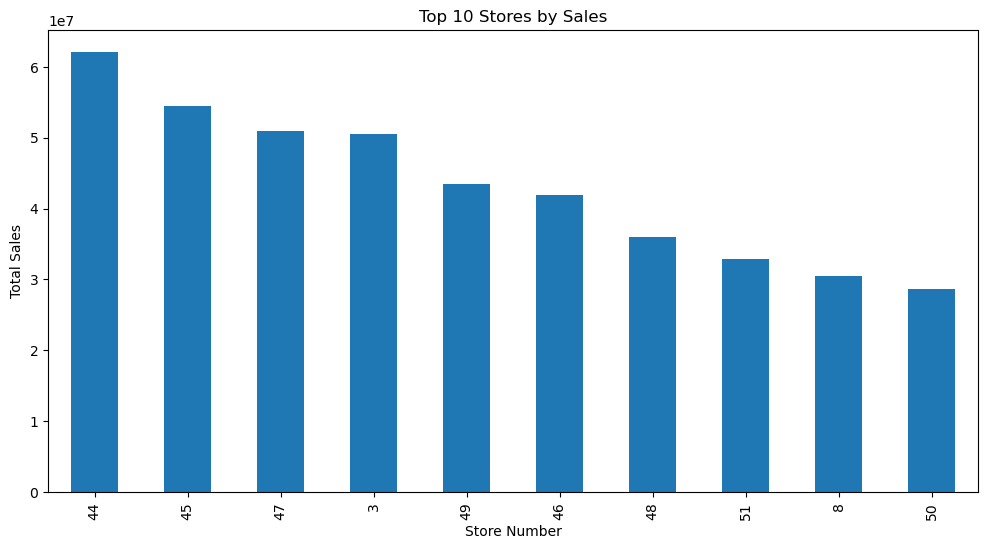

In [22]:
plt.figure(figsize=(12,6))

store_sales.head(10).plot(kind='bar')

plt.title("Top 10 Stores by Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")

plt.show()

In [23]:
store_sales.head(10).apply(lambda x: round(x/1000000,2))

store_nbr
44    62.09
45    54.50
47    50.95
3     50.48
49    43.42
46    41.90
48    35.93
51    32.91
8     30.49
50    28.65
Name: sales, dtype: float64

In [24]:
store_sales.describe()

count    5.400000e+01
mean     1.988231e+07
std      1.329537e+07
min      2.696170e+06
25%      1.109715e+07
50%      1.599205e+07
75%      2.482969e+07
max      6.208755e+07
Name: sales, dtype: float64

In [25]:
print("next is stockout risk analysis")


next is stockout risk analysis


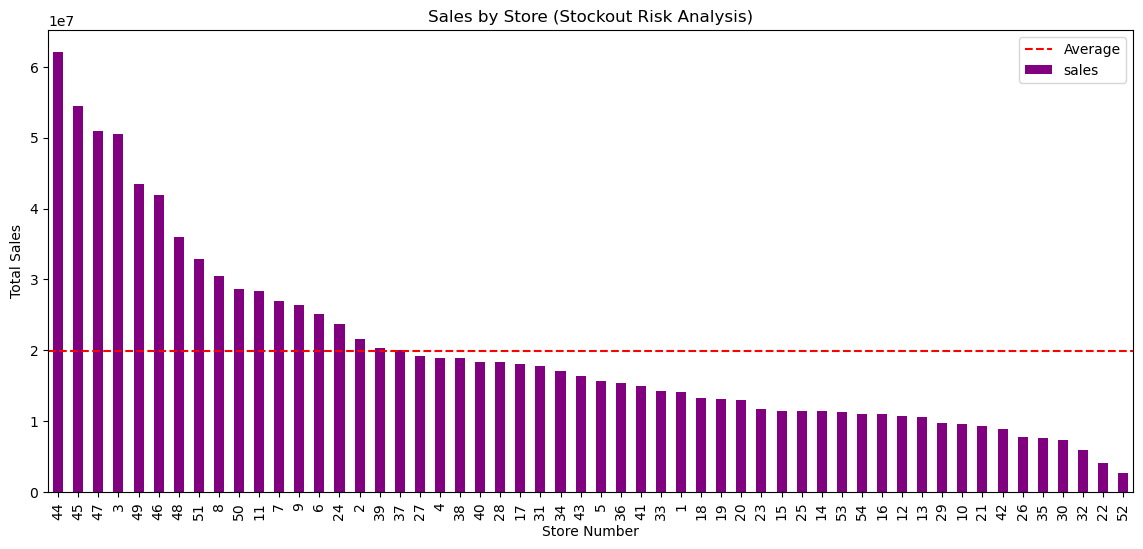

In [26]:
average_sales = store_sales.mean()

plt.figure(figsize=(14,6))

store_sales.sort_values(ascending=False).plot(
    kind='bar',
    color='purple'
)

plt.axhline(
    average_sales,
    color='red',
    linestyle='--',
    label='Average'
)

plt.title("Sales by Store (Stockout Risk Analysis)")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.legend()

plt.show()

In [27]:
train[['sales', 'onpromotion']].corr()

,sales,onpromotion
sales,1.000000,0.427923
onpromotion,0.427923,1.000000


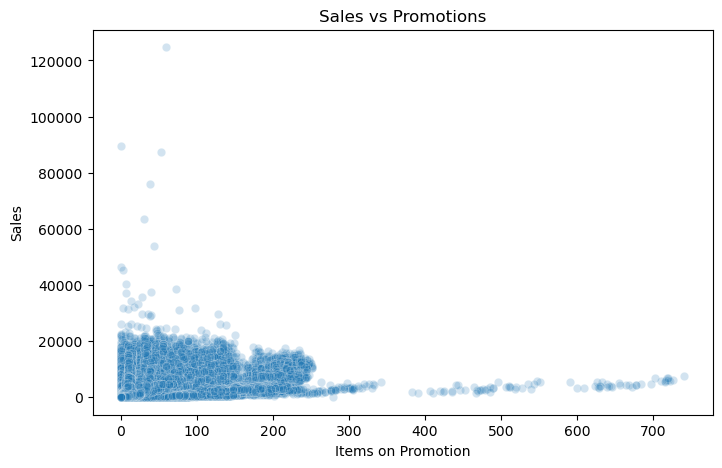

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train['onpromotion'],
    y=train['sales'],
    alpha=0.2
)

plt.title("Sales vs Promotions")
plt.xlabel("Items on Promotion")
plt.ylabel("Sales")

plt.show()

In [29]:
promo_analysis = train.copy()

promo_analysis['Promo_Flag'] = promo_analysis['onpromotion'] > 0

promo_analysis.groupby('Promo_Flag')['sales'].mean()

Promo_Flag
False     158.246681
True     1137.693730
Name: sales, dtype: float64

In [1]:
train['date'] = pd.to_datetime(train['date'])

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train.head()

NameError: name 'train' is not defined

In [4]:
train = pd.read_csv("../train.csv")
stores = pd.read_csv("../stores.csv")
transactions = pd.read_csv("../transactions.csv")
oil = pd.read_csv("../oil.csv")
holidays = pd.read_csv("../holidays_events.csv")

In [5]:
print(type(train))

<class 'pandas.core.frame.DataFrame'>


In [6]:
train['date'] = pd.to_datetime(train['date'])

In [7]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['weekday'] = train['date'].dt.day_name()

train[['date','year','month','day','weekday']].head()

,date,year,month,day,weekday
0,2013-01-01,2013,1,1,Tuesday
1,2013-01-01,2013,1,1,Tuesday
2,2013-01-01,2013,1,1,Tuesday
3,2013-01-01,2013,1,1,Tuesday
4,2013-01-01,2013,1,1,Tuesday


In [8]:
monthly_sales = train.groupby(
    ['year','month']
)['sales'].sum()

In [9]:
monthly_sales = train.groupby(
    ['year','month']
)['sales'].sum()

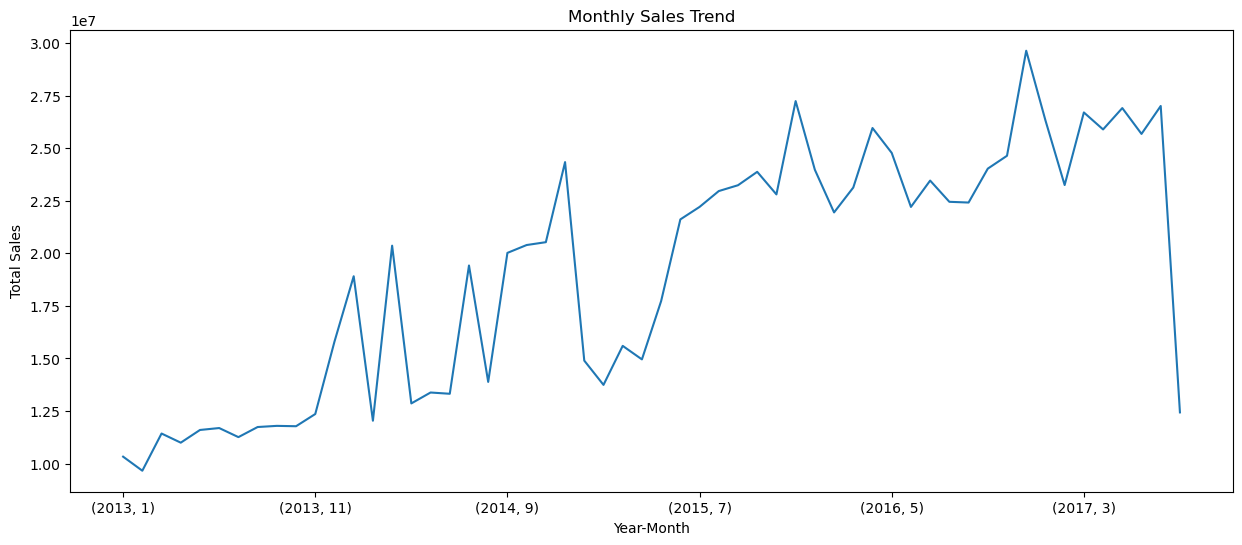

In [10]:
plt.figure(figsize=(15,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")

plt.show()

In [11]:
monthly_sales = train.groupby(
    ['year','month']
)['sales'].sum().reset_index()

monthly_sales.head()

,year,month,sales
0,2013,1,1.032762e+07
1,2013,2,9.658960e+06
2,2013,3,1.142850e+07
3,2013,4,1.099346e+07
4,2013,5,1.159770e+07


In [12]:
monthly_sales['year_month'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' +
    monthly_sales['month'].astype(str)
)

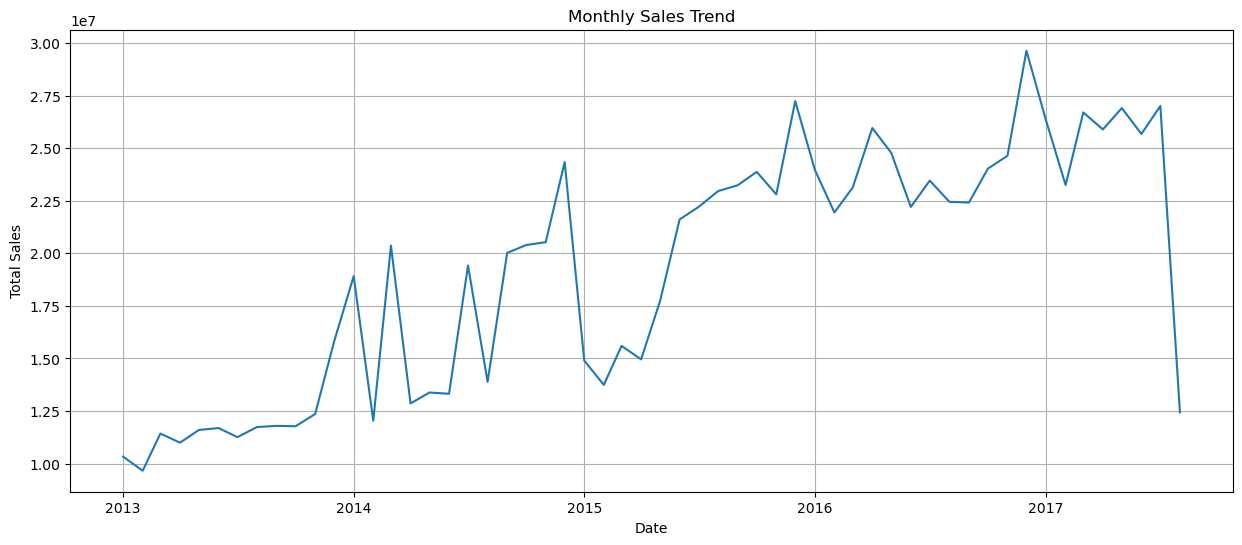

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['sales']
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

In [14]:
month_sales = train.groupby('month')['sales'].mean()

month_sales


month
1     341.921554
2     320.928869
3     352.009294
4     339.199841
5     341.765820
6     353.597842
7     374.219111
8     336.992535
9     362.297418
10    362.407132
11    375.681762
12    453.740370
Name: sales, dtype: float64

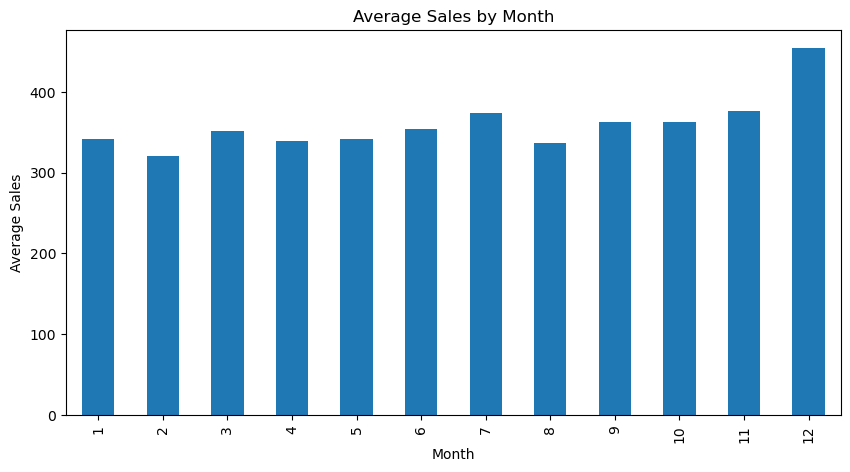

In [15]:
plt.figure(figsize=(10,5))

month_sales.plot(kind='bar')

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

In [17]:
print("Seasonality analysis showed that December recorded the highest average sales while February had the lowest. This indicated strong year-end demand patterns, which can be leveraged for inventory planning and promotional strategy.")

Seasonality analysis showed that December recorded the highest average sales while February had the lowest. This indicated strong year-end demand patterns, which can be leveraged for inventory planning and promotional strategy.


In [18]:
!pip show prophet

Name: prophet
Version: 1.3.0
Summary: Automatic Forecasting Procedure
Home-page: https://facebook.github.io/prophet/
Author: 
Author-email: "Sean J. Taylor" <sjtz@pm.me>, Ben Letham <bletham@fb.com>
License: MIT
Location: C:\Users\Kritika Goel\anaconda3\Lib\site-packages
Requires: cmdstanpy, holidays, importlib_resources, matplotlib, numpy, pandas, tqdm
Required-by: 


In [19]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [20]:
prophet_data = daily_sales.rename(
    columns={
        'date':'ds',
        'sales':'y'
    }
)

prophet_data.head()

,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [21]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_data)

18:27:52 - cmdstanpy - INFO - Chain [1] start processing
18:27:53 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

In [23]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,335914.011763,234230.401146,519264.138202,335914.011763,335914.011763,43331.939765,43331.939765,43331.939765,-68169.444647,-68169.444647,-68169.444647,111501.384412,111501.384412,111501.384412,0.0,0.0,0.0,379245.951528
1,2013-01-02,336282.111147,257074.567422,533049.653142,336282.111147,336282.111147,55306.539352,55306.539352,55306.539352,-44223.766432,-44223.766432,-44223.766432,99530.305785,99530.305785,99530.305785,0.0,0.0,0.0,391588.650499
2,2013-01-03,336650.210531,161580.507228,428335.740808,336650.210531,336650.210531,-44331.367000,-44331.367000,-44331.367000,-131872.713441,-131872.713441,-131872.713441,87541.346440,87541.346440,87541.346440,0.0,0.0,0.0,292318.843531
3,2013-01-04,337018.309916,213767.748098,493851.454665,337018.309916,337018.309916,18638.594132,18638.594132,18638.594132,-57074.388340,-57074.388340,-57074.388340,75712.982472,75712.982472,75712.982472,0.0,0.0,0.0,355656.904048
4,2013-01-05,337386.409300,400181.063126,678143.296605,337386.409300,337386.409300,198255.107629,198255.107629,198255.107629,134041.565460,134041.565460,134041.565460,64213.542170,64213.542170,64213.542170,0.0,0.0,0.0,535641.516929


In [25]:
print("Where ds = date
yhat = predicted sales
yhat_lower = pessimistic estimate
yhat_upper = optimistic estimate")

SyntaxError: unterminated string literal (detected at line 1) (2634440640.py, line 1)

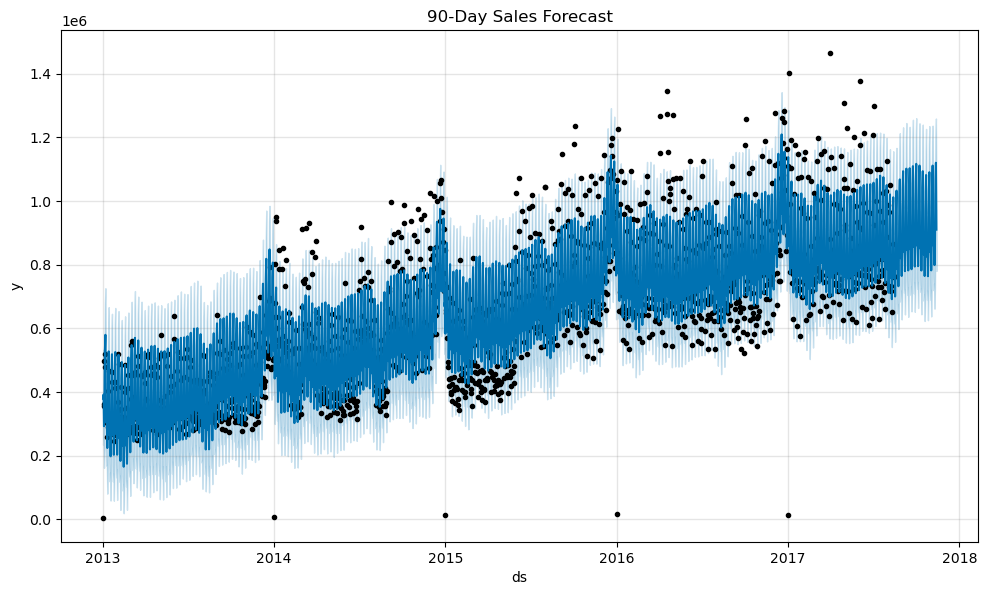

In [26]:
fig1 = model.plot(forecast)
plt.title("90-Day Sales Forecast")
plt.show()

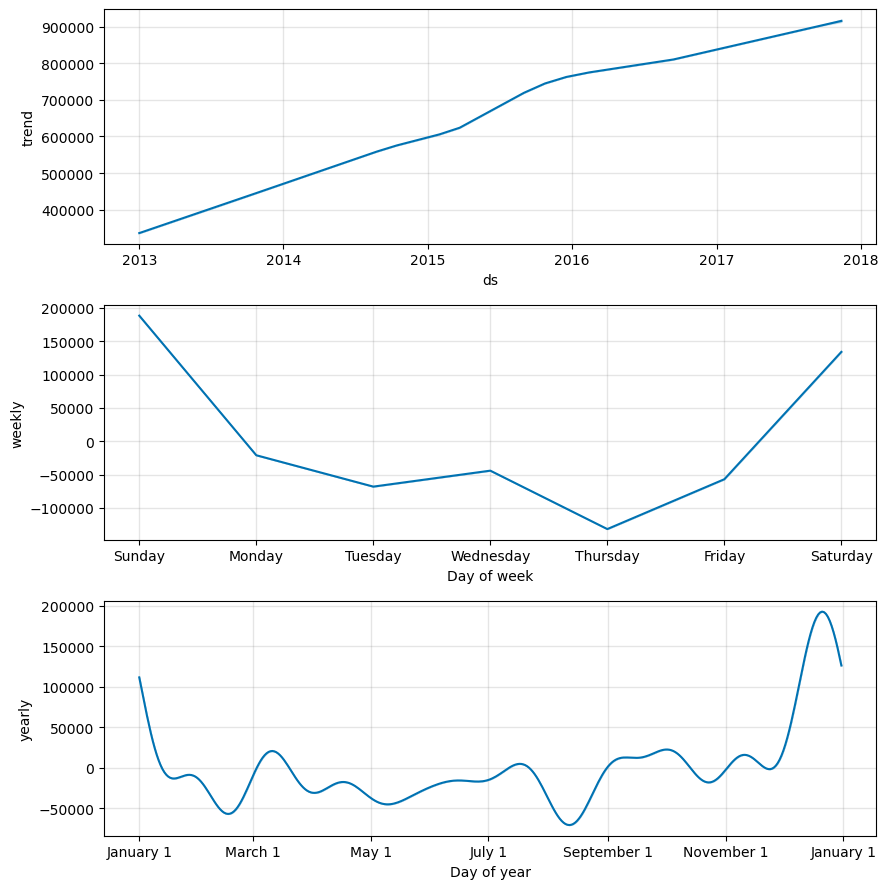

In [27]:
fig2 = model.plot_components(forecast)
plt.show()

# Prophet Forecasting Analysis

## Model Overview

Meta Prophet was used for time-series forecasting on daily FMCG sales data. The model was trained on historical sales records from 2013 to 2017 after performing feature engineering and seasonality analysis.

---

## 90-Day Sales Forecast

### Actual vs Predicted Sales

- Black Dots represent actual historical sales observations.
- Blue Line represents Prophet's forecasted sales values.
- Light Blue Region represents the confidence interval (uncertainty range) of predictions.

The forecast indicates that future demand is expected to continue following the long-term upward growth trend observed in historical data.

---

## Trend Analysis

The trend component shows a significant increase in demand over time.

- Early 2013 demand: approximately **350,000 sales units/day**
- Late 2017 demand: approximately **920,000 sales units/day**

This indicates that overall sales demand nearly tripled during the observation period, suggesting strong business growth.

---

## Weekly Seasonality Analysis

The model identified clear weekly demand patterns:

### Highest Demand Days
- Sunday
- Saturday

### Lowest Demand Days
- Thursday
- Tuesday

This suggests that customers make more purchases during weekends, which is typical for retail and FMCG businesses.

---

## Yearly Seasonality Analysis

The yearly seasonality component revealed strong seasonal demand patterns.

### Peak Demand Period
- December

### Lower Demand Periods
- February and certain mid-year months

This aligns with the earlier EDA findings where December recorded the highest average monthly sales (~454 units) while February recorded the lowest (~321 units).

The year-end spike is likely driven by holiday shopping, festive demand, and promotional campaigns.

---

## Business Insights

- Product promotions resulted in approximately **7.2x higher average sales** compared to non-promotional products.
- Quito generated the highest city-level revenue (~556.7 million).
- Store 44 was the highest-performing store with approximately **62.09 million** in total sales.
- Grocery I was the highest-selling product family.
- December showed the strongest seasonal demand.

---

## Conclusion

The Prophet forecasting model successfully captured:

- Long-term business growth trends
- Weekly demand seasonality
- Yearly seasonal patterns
- Future demand projections

These insights can support inventory planning, demand forecasting, stock allocation, and promotional strategy decisions in FMCG retail operations.

In [1]:
monthly_sales.to_csv("monthly_sales.csv", index=False)

NameError: name 'monthly_sales' is not defined

In [2]:
train = pd.read_csv("../train.csv")

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv("../train.csv")

In [5]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month

monthly_sales = train.groupby(
    ['year','month']
)['sales'].sum().reset_index()

monthly_sales['year_month'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' +
    monthly_sales['month'].astype(str)
)

monthly_sales.head()

,year,month,sales,year_month
0,2013,1,1.032762e+07,2013-01-01
1,2013,2,9.658960e+06,2013-02-01
2,2013,3,1.142850e+07,2013-03-01
3,2013,4,1.099346e+07,2013-04-01
4,2013,5,1.159770e+07,2013-05-01


In [6]:
monthly_sales.to_csv("monthly_sales.csv", index=False)